# MNIST CNN Tuning with KerasTuner

This complete workflow treats tuning as a validation experiment. Both frameworks use the
same seed-42 split, discrete search space, four-trial budget, ten-epoch maximum,
and validation accuracy objective.

To run the search more quickly, reduce `TRIALS` or `SEARCH_EPOCHS` below.

## Runtime dependency check

In [1]:
import importlib.util
import subprocess
import sys
from pathlib import Path

REQUIRED_RUNTIME = {'keras': 'keras', 'torch': 'torch'}
COLAB_EXTRAS = {'keras_tuner': 'keras-tuner'}
missing_required = [
    package for module, package in REQUIRED_RUNTIME.items()
    if importlib.util.find_spec(module) is None
]
missing_extras = [
    package for module, package in COLAB_EXTRAS.items()
    if importlib.util.find_spec(module) is None
]
if missing_extras and "google.colab" in sys.modules:
    subprocess.check_call(
        [sys.executable, "-m", "pip", "install", "-q", *missing_extras]
    )
    missing_extras = []
if missing_required or missing_extras:
    missing = ", ".join(missing_required + missing_extras)
    raise RuntimeError(
        f"Missing notebook dependencies: {missing}. Locally run "
        "`uv sync --group notebooks`; in Colab restart the runtime if an "
        "installation cell just changed the environment."
    )
print("runtime dependency check passed")

runtime dependency check passed


In [2]:
%matplotlib inline

## Keras-to-PyTorch crosswalk

This optional implementation uses the same Torch runtime as the canonical
native PyTorch path. Keras `compile()` selects the optimizer and loss,
`fit()` owns the explicit batch and epoch loop, and callbacks provide
high-level training control. Data, splits, budgets, evidence, and scientific
conclusions remain aligned with the canonical PyTorch workflow.

## Imports and shared split

In [3]:
import hashlib
import json
import os

os.environ["KERAS_BACKEND"] = "torch"

import keras
import matplotlib.pyplot as plt
import numpy as np
import torch
from keras import layers
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
)
from sklearn.model_selection import train_test_split

assert keras.backend.backend() == "torch"
print(
    f"Keras {keras.__version__}; backend={keras.backend.backend()}; "
    f"PyTorch {torch.__version__}"
)

import importlib.util
import subprocess
import sys
from pathlib import Path
if importlib.util.find_spec("keras_tuner") is None:
    subprocess.check_call(
        [sys.executable, "-m", "pip", "install", "-q", "keras-tuner>=1.4,<2"]
    )
import keras_tuner as kt

Keras 3.15.1; backend=torch; PyTorch 2.13.0


In [4]:
SEED = 42
EPOCHS = 5  # Reduce to 1 or 2 for a quicker run.
BATCH_SIZE = 128

keras.utils.set_random_seed(SEED)
torch.use_deterministic_algorithms(True)

(x_development, y_development), (x_test, y_test) = keras.datasets.mnist.load_data()
all_indices = np.arange(len(y_development))
train_indices, validation_indices = train_test_split(
    all_indices,
    test_size=10000,
    random_state=SEED,
    stratify=y_development,
)
split_signature = hashlib.sha256(
    validation_indices.astype("<i8").tobytes()
).hexdigest()[:16]

x_train = x_development[train_indices].astype("float32") / 255.0
y_train = y_development[train_indices].astype(np.int64)
x_validation = x_development[validation_indices].astype("float32") / 255.0
y_validation = y_development[validation_indices].astype(np.int64)
x_test = x_test.astype("float32") / 255.0
y_test = y_test.astype(np.int64)
x_train = x_train[..., np.newaxis]
x_validation = x_validation[..., np.newaxis]
x_test = x_test[..., np.newaxis]

assert set(train_indices).isdisjoint(validation_indices)
print(f"split signature: {split_signature}")
print(
    f"train={len(y_train):,}, validation={len(y_validation):,}, "
    f"test={len(y_test):,}, epochs={EPOCHS}"
)

split signature: 829d1431018b38bc
train=50,000, validation=10,000, test=10,000, epochs=5


## Fixed search contract

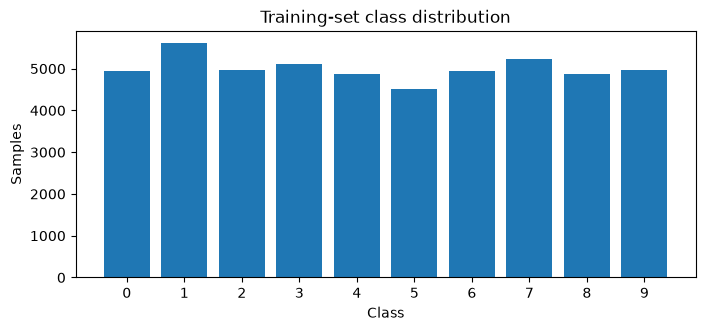

In [5]:
training_counts = np.bincount(y_train, minlength=10)
fig, ax = plt.subplots(figsize=(8, 3.2))
ax.bar(np.arange(10), training_counts)
ax.set(
    title="Training-set class distribution",
    xlabel="Class",
    ylabel="Samples",
    xticks=np.arange(10),
)
plt.show()

TRIALS = 4  # Reduce to 2 for a quicker search.
SEARCH_EPOCHS = 10  # Reduce to 1 or 2 for quicker trials.
SEARCH_SPACE = {
    "filters_1": [16, 32],
    "filters_2": [32, 64],
    "dense_units": [100, 200],
    "learning_rate": [1e-2, 1e-3, 1e-4],
}

## Run KerasTuner

In [6]:
def build_model(hp):
    model = keras.Sequential(
        [
            keras.Input(shape=(28, 28, 1)),
            layers.Conv2D(hp.Choice("filters_1", SEARCH_SPACE["filters_1"]), 3, activation="relu"),
            layers.MaxPooling2D(),
            layers.Conv2D(hp.Choice("filters_2", SEARCH_SPACE["filters_2"]), 3, activation="relu"),
            layers.MaxPooling2D(),
            layers.Dropout(0.25),
            layers.Flatten(),
            layers.Dense(hp.Choice("dense_units", SEARCH_SPACE["dense_units"]), activation="relu"),
            layers.Dropout(0.5),
            layers.Dense(10),
        ]
    )
    model.compile(
        optimizer=keras.optimizers.Adam(
            hp.Choice("learning_rate", SEARCH_SPACE["learning_rate"])
        ),
        loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
        metrics=["accuracy"],
    )
    return model


tuner = kt.RandomSearch(
    build_model,
    objective="val_accuracy",
    max_trials=TRIALS,
    seed=SEED,
    overwrite=True,
    directory=str(Path(os.getenv("HELIO_TUNER_DIR", "/tmp")) / "helio-keras-tuner"),
    project_name="mnist-cnn",
)
tuner.search(
    x_train,
    y_train,
    validation_data=(x_validation, y_validation),
    epochs=SEARCH_EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[keras.callbacks.EarlyStopping("val_loss", patience=2)],
    verbose=0,
)
best_parameters = tuner.get_best_hyperparameters(1)[0]
print("best parameters:", best_parameters.values)

best parameters: {'filters_1': 32, 'filters_2': 32, 'dense_units': 100, 'learning_rate': 0.001}


## Rebuild the selected model and evaluate once

In [7]:
model = tuner.hypermodel.build(best_parameters)
history = model.fit(
    x_train,
    y_train,
    validation_data=(x_validation, y_validation),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=2,
)

Epoch 1/5


391/391 - 8s - 21ms/step - accuracy: 0.8558 - loss: 0.4540 - val_accuracy: 0.9692 - val_loss: 0.1033


Epoch 2/5


391/391 - 8s - 21ms/step - accuracy: 0.9550 - loss: 0.1523 - val_accuracy: 0.9786 - val_loss: 0.0731


Epoch 3/5


391/391 - 8s - 21ms/step - accuracy: 0.9673 - loss: 0.1098 - val_accuracy: 0.9844 - val_loss: 0.0552


Epoch 4/5


391/391 - 8s - 20ms/step - accuracy: 0.9722 - loss: 0.0907 - val_accuracy: 0.9842 - val_loss: 0.0538


Epoch 5/5


391/391 - 8s - 21ms/step - accuracy: 0.9758 - loss: 0.0796 - val_accuracy: 0.9863 - val_loss: 0.0479


test accuracy: 0.9869
              precision    recall  f1-score   support

           0      0.979     0.995     0.987       980
           1      0.989     0.996     0.993      1135
           2      0.985     0.990     0.987      1032
           3      0.983     0.989     0.986      1010
           4      0.988     0.995     0.991       982
           5      0.989     0.982     0.985       892
           6      0.996     0.985     0.991       958
           7      0.981     0.984     0.983      1028
           8      0.993     0.979     0.986       974
           9      0.989     0.970     0.979      1009

    accuracy                          0.987     10000
   macro avg      0.987     0.987     0.987     10000
weighted avg      0.987     0.987     0.987     10000

HELIO_RESULT {"confusion_shape": [10, 10], "split_signature": "829d1431018b38bc", "test_accuracy": 0.9869}


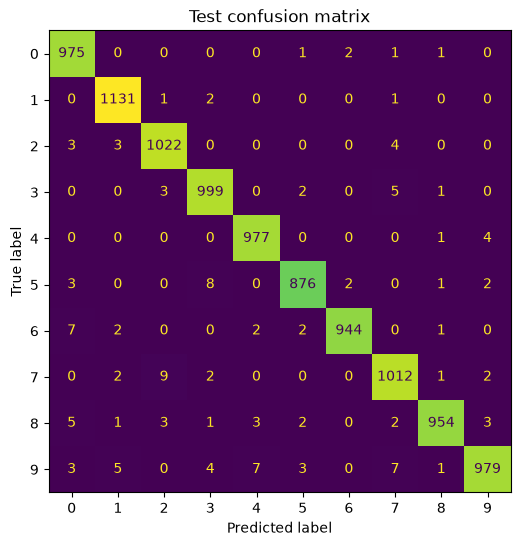

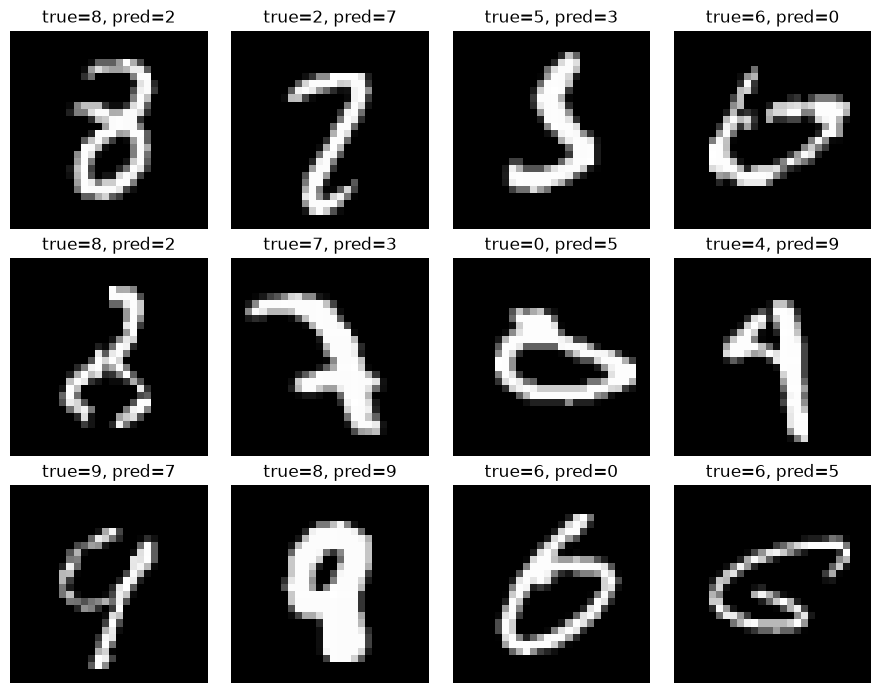

In [8]:
test_logits = model.predict(x_test, batch_size=BATCH_SIZE, verbose=0)
test_predictions = test_logits.argmax(axis=1)

test_accuracy = accuracy_score(y_test, test_predictions)
cm = confusion_matrix(y_test, test_predictions, labels=np.arange(10))
print(f"test accuracy: {test_accuracy:.4f}")
print(
    classification_report(
        y_test,
        test_predictions,
        labels=np.arange(10),
        digits=3,
        zero_division=0,
    )
)
print(
    "HELIO_RESULT "
    + json.dumps(
        {
            "split_signature": split_signature,
            "test_accuracy": float(test_accuracy),
            "confusion_shape": list(cm.shape),
        },
        sort_keys=True,
    )
)
assert cm.shape == (10, 10)

fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay(cm, display_labels=np.arange(10)).plot(
    ax=ax, colorbar=False, values_format="d"
)
ax.set_title("Test confusion matrix")
plt.show()

mistakes = np.flatnonzero(test_predictions != y_test)[:12]
if len(mistakes):
    fig, axes = plt.subplots(3, 4, figsize=(9, 7))
    for axis, index in zip(axes.flat, mistakes):
        image = x_test[index]
        if image.shape[0] in (1, 3):
            image = np.transpose(image, (1, 2, 0))
        axis.imshow(image.squeeze(), cmap="gray" if image.squeeze().ndim == 2 else None)
        axis.set_title(f"true={y_test[index]}, pred={test_predictions[index]}")
        axis.axis("off")
    plt.tight_layout()
    plt.show()

## Try it yourself in Keras

Change one choice at a time and keep the data split and evaluation unchanged:

- add dropout values to the search space.
- increase the number of trials and inspect whether the result is stable.
- repeat the search with a second sampler seed.